# Model for Predicting Customer Churn for a Coffee Delivery Service

# Customer Churn Prediction for Happy Beans Coffee Delivery Service

---

## Research Description

Happy Beans Coffee launched a coffee delivery service and faced the problem of customer churn — the service loses about 10% of its customer base every month. Acquiring a new customer costs 5–7 times more than retaining an existing one, so accurate churn prediction will allow the company to efficiently allocate its marketing budget and take timely measures to retain customers.

---

## Research Goal

Build a binary classification model that accurately determines the customer status: **"Loyal"** or **"At Risk"** — thereby enabling the business to proactively work with potentially leaving customers.

---

## Research Tasks

1. Conduct exploratory data analysis (EDA): study feature distributions, identify missing values, outliers, and correlations
2. Perform data preprocessing: fill missing values, handle outliers, encode categorical features
3. Train a baseline model (DummyClassifier) as a reference point
4. Generate new features and evaluate their impact on model quality
5. Tune LogisticRegression hyperparameters using GridSearchCV
6. Evaluate the final model on a hold-out test set
7. Save the model and preprocessing pipeline for production use

---

## Machine Learning Problem Statement

- **Problem type:** binary classification
- **Learning type:** supervised learning
- **Target variable:** `churn` (0 — loyal customer, 1 — leaving customer)
- **Primary metric:** PR AUC (Precision-Recall AUC) — recommended due to strong class imbalance. Accuracy is unsuitable in this case
- **Algorithm:** LogisticRegression — a linear model that allows interpreting coefficients to understand which factors influence churn

---

## Source Data

The dataset `coffee_churn_dataset.csv` contains information on **10,450 customers** with **26 features**, aggregated over the last 4 weeks. Data was collected from transactional databases, mobile app logs, and survey results.

Features include:
- **Transactional behavior:** order frequency, average check, total spending, discount usage
- **App activity:** number of opens, app crashes, notifications
- **Preferences:** coffee type, roast, milk, drink size
- **Contextual:** season, device type, region, subscription status

# Work Plan

## Stage 1. Environment and Libraries Setup
1. Install and configure the libraries. To ensure reproducibility of results, lock the package versions in the `requirements.txt` file.

2. Fix the `random_state`.

3. Load data from the CSV file. File path: `'/datasets/coffee_churn_dataset.csv'`. Use the separator `","`, and for reading floating-point numbers — the parameter `decimal="."`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, average_precision_score, log_loss
from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.model_selection import GridSearchCV

import joblib

In [2]:
RANDOM_STATE = 42

In [3]:
df = pd.read_csv('/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')

## Stage 2. Initial Data Analysis

### Data Description

In [4]:
df.head(10)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1
5,user_01247,0.0,1.284824,0.418197,1092.164843,338.082043,471.825472,159.366225,0.350490,arabica,...,0.0,4.235214,4.835587,1.0,winter,17.0,android,0.0,geo_68,0
6,user_08887,5.0,6.124180,1.214905,428.486273,174.449445,1088.359993,254.120345,0.146130,robusta,...,NaN,4.406612,4.144391,0.0,spring,9.0,android,0.0,geo_3,0
7,user_01885,3.0,4.640247,1.029297,27.368788,9.812365,NaN,10.523663,0.173646,robusta,...,1.0,4.793547,4.321319,3.0,NaN,12.0,android,0.0,geo_3,1
8,user_03703,9.0,3.303446,NaN,1886.543949,964.629212,3312.557597,748.655191,0.676576,blend,...,1.0,4.405572,NaN,0.0,spring,5.0,android,0.0,geo_45,0
9,user_01536,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,...,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


The dataset contains information on 10,450 clients and 26 features. The data is aggregated over the last 4 weeks and covers transactional behavior, app activity, and user preferences. At first glance, it is clear that the data is inconsistent, contains missing values, and some negative data - the dataset requires thorough preprocessing.

### Working with the target variable

In [6]:
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

churn_counts
churn_pct.round(2)


0    93.98
1     6.02
Name: churn, dtype: float64

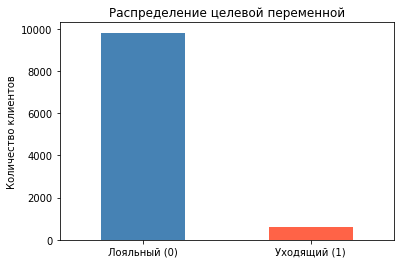

In [7]:
churn_counts.plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Target Variable Distribution')
plt.xticks([0, 1], ['Loyal (0)', 'Churning (1)'], rotation=0)
plt.ylabel('Number of Customers')
plt.show()

From the graph, it is clear that the classes are highly imbalanced: 94% loyal versus 6% leaving, so the recommendation to use PR AUC as a metric is justified.

### Feature Description

In [8]:
df.columns.tolist()

['user_id',
 'days_since_last_order',
 'order_frequency_month',
 'order_frequency_week',
 'avg_order_value',
 'median_order_value',
 'total_spent_last_month',
 'total_spent_last_week',
 'discount_usage_rate',
 'last_coffee_type',
 'preferred_roast',
 'milk_preference',
 'seasonal_menu_tried',
 'coffee_bean_origin',
 'last_drink_size',
 'subscription_status',
 'app_opens_per_week',
 'notifications_enabled',
 'review_rating_last_10',
 'review_rating_last_1',
 'app_crashes_last_month',
 'seasons',
 'days_since_last_promo',
 'phone_type',
 'coffee_preference_change',
 'geo_location',
 'churn']

Judging by the description of the features, the working strategy should be as follows:

- user_id: unique identifier, 10450 unique values. No predictive power - remove
- days_since_last_order: may be useful - the longer no orders, the higher the churn risk (keep)
- order_frequency_month / order_frequency_week: order frequency, a direct signal of activity (keep)
- avg_order_value / median_order_value: average and median check (keep)
- total_spent_last_month / total_spent_last_week: total spending (keep)
- discount_usage_rate: proportion of orders with a discount (keep)
- last_coffee_type, preferred_roast, milk_preference, coffee_bean_origin, last_drink_size: questionable. Taste preferences may not be directly related to churn, but coffee_preference_change (whether preferences changed) may be more important than the preferences themselves. We will decide after correlation analysis
- seasonal_menu_tried: tried seasonal menu - may be an indirect engagement signal (keep)
- app_opens_per_week: direct engagement signal (keep)
- notifications_enabled: notifications enabled or not (keep)
- app_crashes_last_month: technical issues may provoke churn (keep)
- review_rating_last_10 / review_rating_last_1: customer satisfaction (keep)
- seasons: data collection season. May affect behavior (keep)
- days_since_last_promo: recency of last promotion (keep)
- phone_type — android/ios/web: Questionable - is device type related to churn? May be indirectly related, keep
- coffee_preference_change: whether preferences changed (keep)
- geo_location: should check for unique values. May be problematic for OHE (if many unique values).
- subscription_status: subscription type, important loyalty signal (keep)

In [9]:
geo_churn = df.groupby('geo_location')['churn'].agg(['mean', 'sum', 'count'])
geo_churn.columns = ['churn_rate', 'churn_count', 'total']
geo_churn = geo_churn.sort_values('churn_rate', ascending=False)
display(geo_churn)

,churn_rate,churn_count,total
geo_location,,,
geo_11,0.173077,9,52
geo_74,0.166667,9,54
geo_47,0.133333,6,45
geo_86,0.131579,5,38
geo_56,0.117647,6,51
...,...,...,...
geo_89,0.015873,1,63
geo_98,0.012500,1,80
geo_8,0.000000,0,65


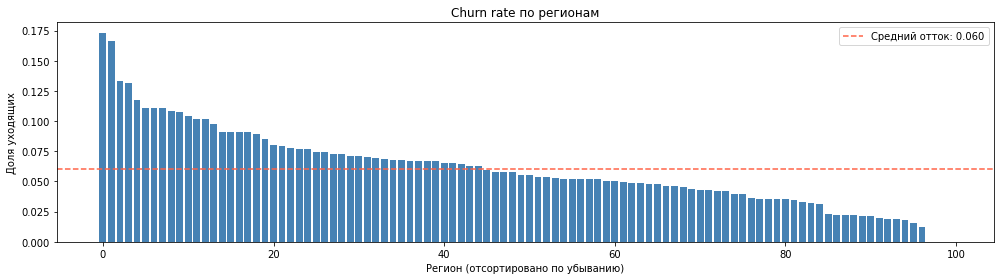

In [10]:
plt.figure(figsize=(14, 4))
plt.bar(range(len(geo_churn)), geo_churn['churn_rate'], color='steelblue')
plt.axhline(df['churn'].mean(), color='tomato', linestyle='--', label=f'Average churn: {df["churn"].mean():.3f}')
plt.title('Churn rate by regions')
plt.xlabel('Region (sorted in descending order)')
plt.ylabel('Proportion of churners')
plt.legend()
plt.tight_layout()
plt.show()

When using OHE, 100 extra columns will be created. It is necessary to separately consider what to do with this feature. It may be worth applying statistical tests to check the hypothesis about the statistical significance of the churn indicator with the region.

In [11]:
df = df.drop(columns=['user_id'])
df.shape

(10450, 26)

### Working with missing values

In [12]:
round((df.isnull().mean() * 100),2)

days_since_last_order       9.04
order_frequency_month       5.74
order_frequency_week        3.71
avg_order_value             5.58
median_order_value          7.95
total_spent_last_month      2.81
total_spent_last_week       9.03
discount_usage_rate         3.80
last_coffee_type            2.47
preferred_roast             1.11
milk_preference             6.39
seasonal_menu_tried         9.46
coffee_bean_origin          6.53
last_drink_size             4.82
subscription_status         8.98
app_opens_per_week          8.57
notifications_enabled       5.14
review_rating_last_10       6.63
review_rating_last_1        8.20
app_crashes_last_month      6.90
seasons                     6.50
days_since_last_promo       7.00
phone_type                  3.22
coffee_preference_change    5.84
geo_location                1.05
churn                       0.00
dtype: float64

In our dataset, there are features for which replacing and/or deleting missing values may mean changing the meaning (for example, days_since_last_order, seasonal_menu_tried, days_since_last_order — we might artificially inflate the proportions of clients, change values for those who possibly really did not order anything or did not open the app at all). It is necessary to test for each feature the hypothesis that the missing values are random and not related to the target variable, by applying appropriate statistical tests.

In [13]:
num_cols = [
    'days_since_last_order', 'order_frequency_month', 'order_frequency_week',
    'avg_order_value', 'median_order_value', 'total_spent_last_month',
    'total_spent_last_week', 'discount_usage_rate', 'app_opens_per_week',
    'review_rating_last_10', 'review_rating_last_1',
    'days_since_last_promo'
]

discrete_cols = [
    'notifications_enabled', 'app_crashes_last_month',
    'coffee_preference_change', 'seasonal_menu_tried'
]

cat_cols = [
    'last_coffee_type', 'preferred_roast', 'milk_preference',
    'coffee_bean_origin', 'last_drink_size', 'subscription_status',
    'seasons', 'phone_type', 'geo_location'
]

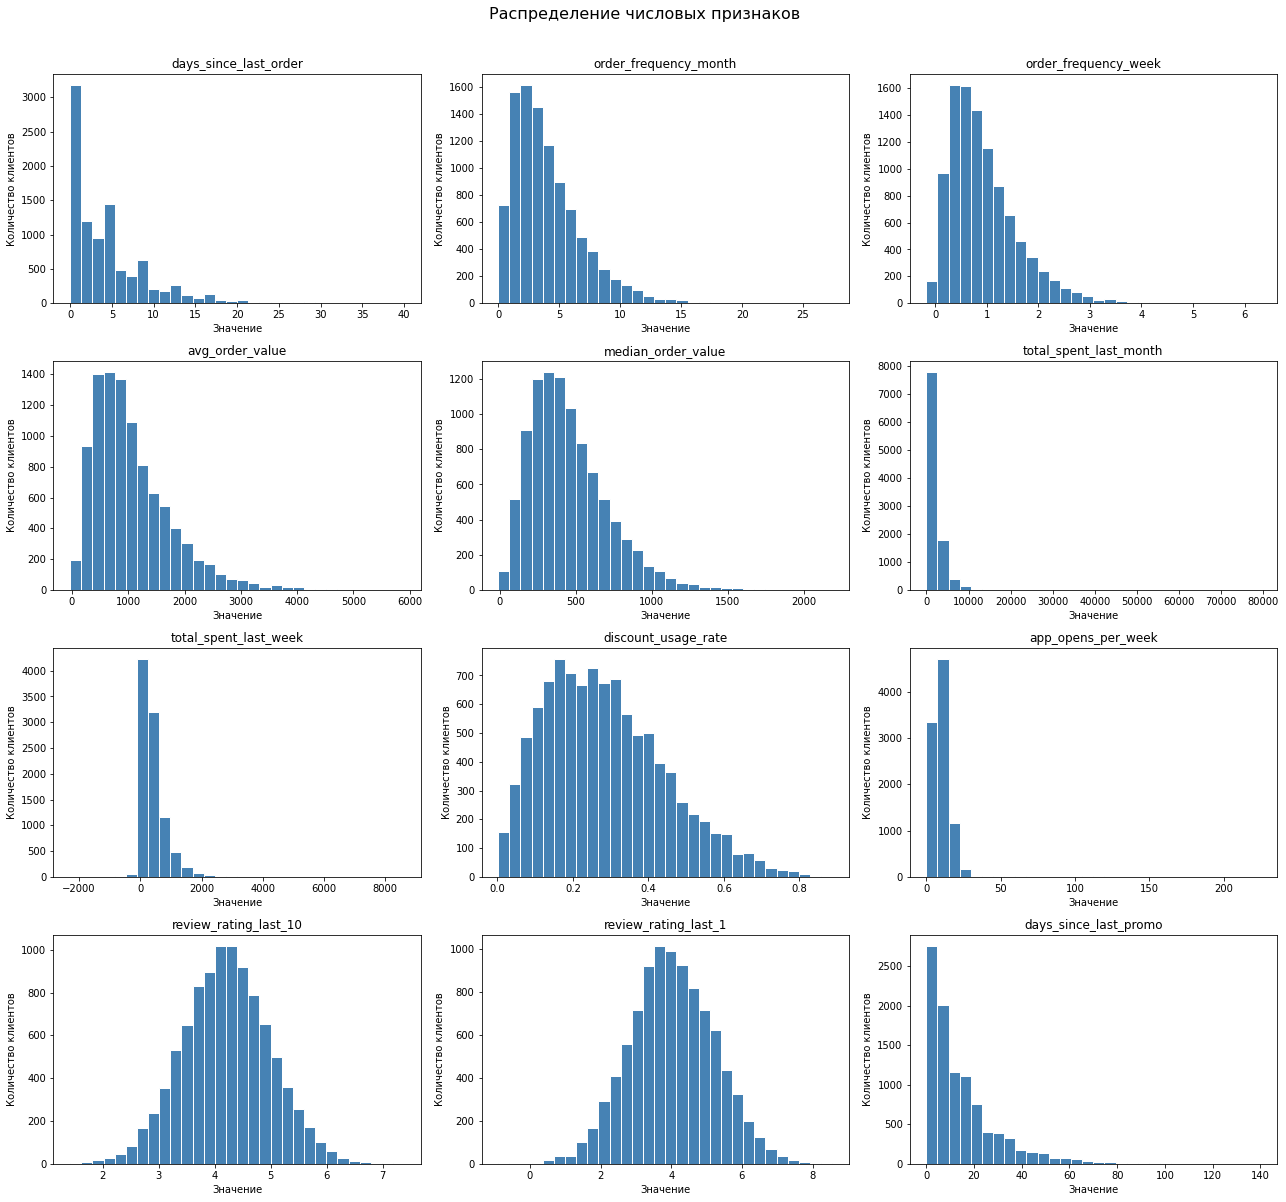

In [14]:
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Number of clients')

# hide extra axes
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of numerical features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

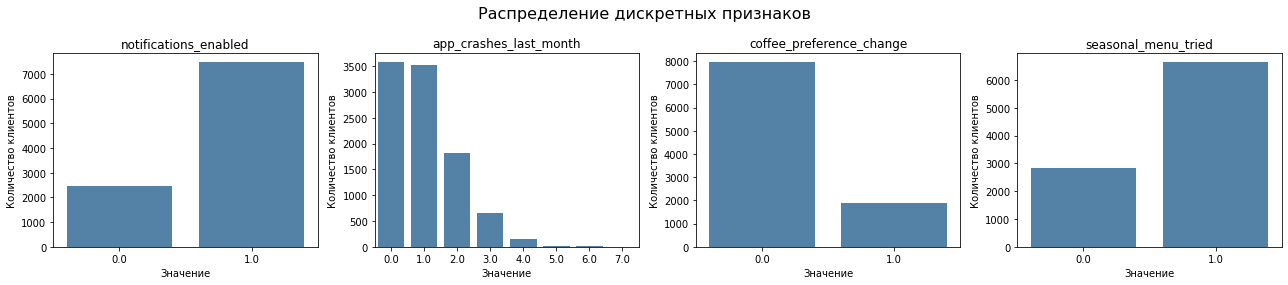

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(discrete_cols):
    sns.countplot(x=df[col].dropna(), ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Number of clients')

plt.suptitle('Distribution of discrete features', fontsize=16)
plt.tight_layout()
plt.show()

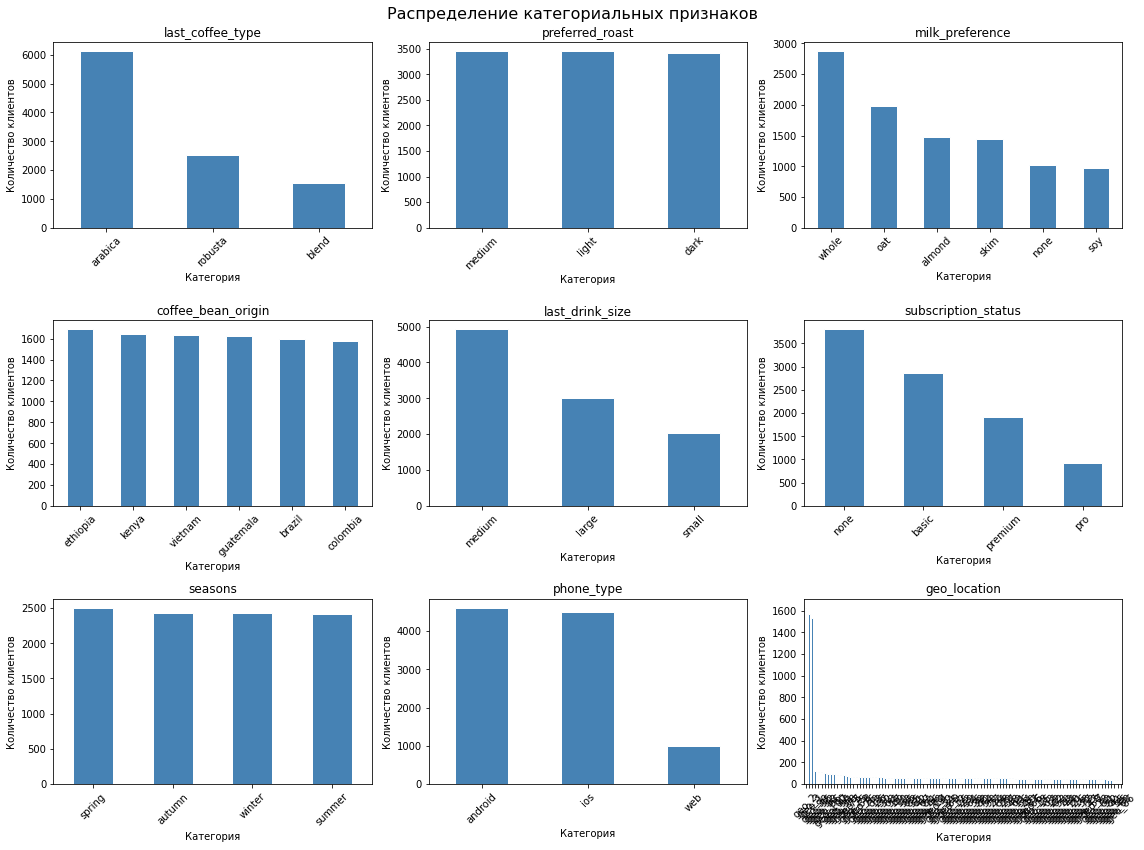

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Number of clients')
    axes[i].tick_params(axis='x', rotation=45)

# hide extra axes
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of categorical features', fontsize=16)
plt.tight_layout()
plt.show()

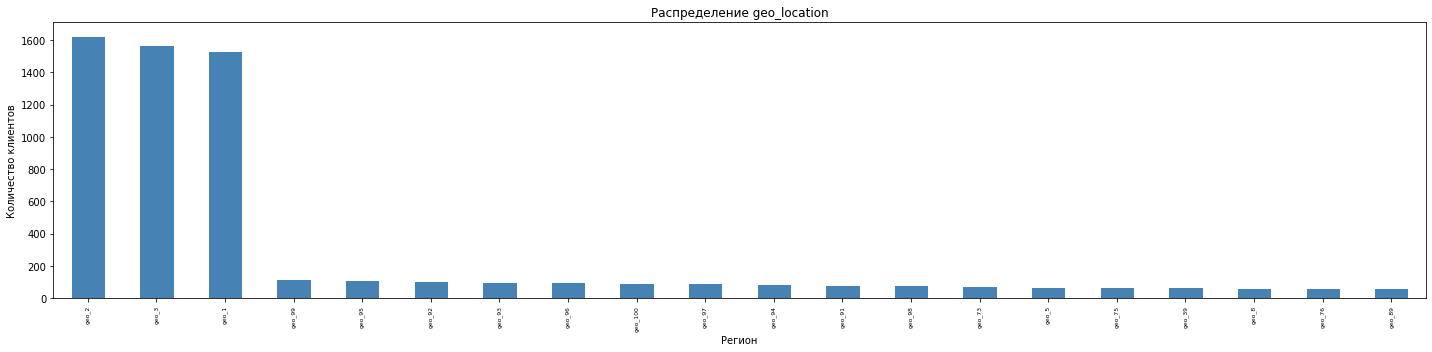

In [17]:
# separately for geo_location due to the large number of unique values
plt.figure(figsize=(20, 5))
df['geo_location'].value_counts().head(20).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribution of geo_location')
plt.xlabel('Region')
plt.ylabel('Number of clients')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

Firstly, from the graphs, it is clear that all numerical features are right-skewed - this means that replacing missing values with the median might be the correct strategy. For categorical features, there is a problem with geolocation - too many unique values make the graph completely unreadable. For binary features, replacing with the mode (which will be the positive value) may distort the picture - decisions should be made only based on the results of statistical tests.

Thus, we get:
- for numerical and binary data, we will apply the Mann-Whitney test
- for categorical data - using the chi-square test

Preliminarily, we will output the negative values in total_spent_last_week

In [18]:
print(f"Negative values: {(df['total_spent_last_week'] < 0).sum()}")
df[df['total_spent_last_week'] < 0]

Отрицательных значений: 171


,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
9,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,light,...,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0
188,3.0,5.019632,1.195954,1546.929497,654.213227,3057.644199,-646.719093,0.055872,arabica,dark,...,0.0,5.249486,5.151920,1.0,winter,NaN,android,1.0,geo_36,0
191,2.0,0.199242,-0.169131,3710.492841,1131.554717,257.097416,-237.899451,0.115694,arabica,light,...,0.0,5.132989,3.098811,2.0,winter,17.0,android,1.0,geo_15,0
193,24.0,2.542895,0.567124,1342.726233,522.184855,1202.395592,-344.924273,0.223425,NaN,light,...,NaN,5.147882,3.638431,2.0,autumn,6.0,android,1.0,geo_76,0
345,2.0,1.132874,-0.074783,715.372314,207.050397,238.475342,-11.382833,0.365909,robusta,light,...,1.0,4.073474,2.330635,2.0,summer,NaN,android,0.0,geo_21,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10003,5.0,3.725641,0.830454,789.809037,348.703243,1316.261165,-271.359227,0.330724,arabica,dark,...,1.0,5.042044,3.491948,2.0,autumn,NaN,android,0.0,geo_3,0
10024,2.0,3.602486,NaN,2359.212558,976.439233,4195.609969,-755.346750,0.373559,arabica,dark,...,1.0,3.907031,NaN,4.0,winter,NaN,ios,1.0,geo_1,1
10025,3.0,1.082639,0.444744,2719.829894,853.413174,806.005470,-334.023706,0.420309,robusta,medium,...,0.0,5.767336,4.913093,1.0,autumn,7.0,android,0.0,geo_3,0
10248,5.0,2.237541,0.380135,2496.586366,763.513805,1816.992342,-275.571784,0.359006,blend,medium,...,0.0,3.144985,5.549957,2.0,autumn,34.0,ios,0.0,geo_2,0


It looks like a simple arithmetic error, since the expense cannot be negative according to the problem statement (unless there are some returns, but most likely they are not considered here). Let's replace everything with absolute values.

In [19]:
df['total_spent_last_week'] = df['total_spent_last_week'].abs()

In [20]:
# applying statistical tests 
for col in df.columns:
    if df[col].isnull().sum() == 0:
        continue
    missing_flag = df[col].isnull().astype(int)
    if df[col].dtype == 'object':
        _, p, _, _ = chi2_contingency(pd.crosstab(missing_flag, df['churn']))
    else:
        _, p = mannwhitneyu(df.loc[missing_flag==0, 'churn'], df.loc[missing_flag==1, 'churn'], alternative='two-sided')
    print(f"{'!!!' if p < 0.05 else 'OK'} {col}: p-value={p:.4f}")

OK days_since_last_order: p-value=0.8725
!!! order_frequency_month: p-value=0.0356
OK order_frequency_week: p-value=0.6086
OK avg_order_value: p-value=0.1104
OK median_order_value: p-value=0.2251
OK total_spent_last_month: p-value=0.2844
OK total_spent_last_week: p-value=0.1879
OK discount_usage_rate: p-value=0.2722
OK last_coffee_type: p-value=0.6014
OK preferred_roast: p-value=0.3298
OK milk_preference: p-value=1.0000
!!! seasonal_menu_tried: p-value=0.0412
OK coffee_bean_origin: p-value=0.8093
!!! last_drink_size: p-value=0.0321
OK subscription_status: p-value=0.3166
OK app_opens_per_week: p-value=0.2440
OK notifications_enabled: p-value=0.8996
OK review_rating_last_10: p-value=0.4360
OK review_rating_last_1: p-value=0.3362
OK app_crashes_last_month: p-value=0.3811
!!! seasons: p-value=0.0351
OK days_since_last_promo: p-value=0.4201
OK phone_type: p-value=0.0717
OK coffee_preference_change: p-value=0.4524
OK geo_location: p-value=1.0000


For 4 features (order_frequency_month, seasonal_menu_tried, last_drink_size, and seasons) the p_value is slightly below 0.05. This means that the fact of missingness may be related to churn and is not random. Since the number of missing values for individual features is large (up to 9%), it does not make sense to delete them, as we may lose some important information related to churn. The most reasonable approach in this case would be to replace the values with the mode/median (and, probably, this can even be justified from a practical point of view through the calculation of confidence intervals).

### Working with Categorical Features

All categorical features with a small number of unique values (last_coffee_type, preferred_roast, milk_preference, coffee_bean_origin, last_drink_size, seasons, phone_type) can and should be encoded using ONE.

Subscription_status can be encoded using OrdinalEncoder since there is an order (none < basic < premium < pro).
For geo_location, we have 100 unique values, OHE will create 100 columns, which is inconvenient to work with. The chi-square criterion showed that these values can be removed, especially since this feature has only 1% missing values.

For generating new features, you can use:

- subscription_status — subscription level as a numerical feature (0,1,2,3)
- review_rating_last_1 and review_rating_last_10 as the difference between the last and average rating (rating_drop = review_rating_last_10 - review_rating_last_1) as a signal of declining satisfaction
- order_frequency_month and order_frequency_week as the ratio of weekly to monthly activity
- total_spent_last_month and total_spent_last_week as the proportion of weekly spending to monthly spending

In [21]:
df = df.drop(columns=['geo_location'])
df.shape

(10450, 25)

### Working with Outliers

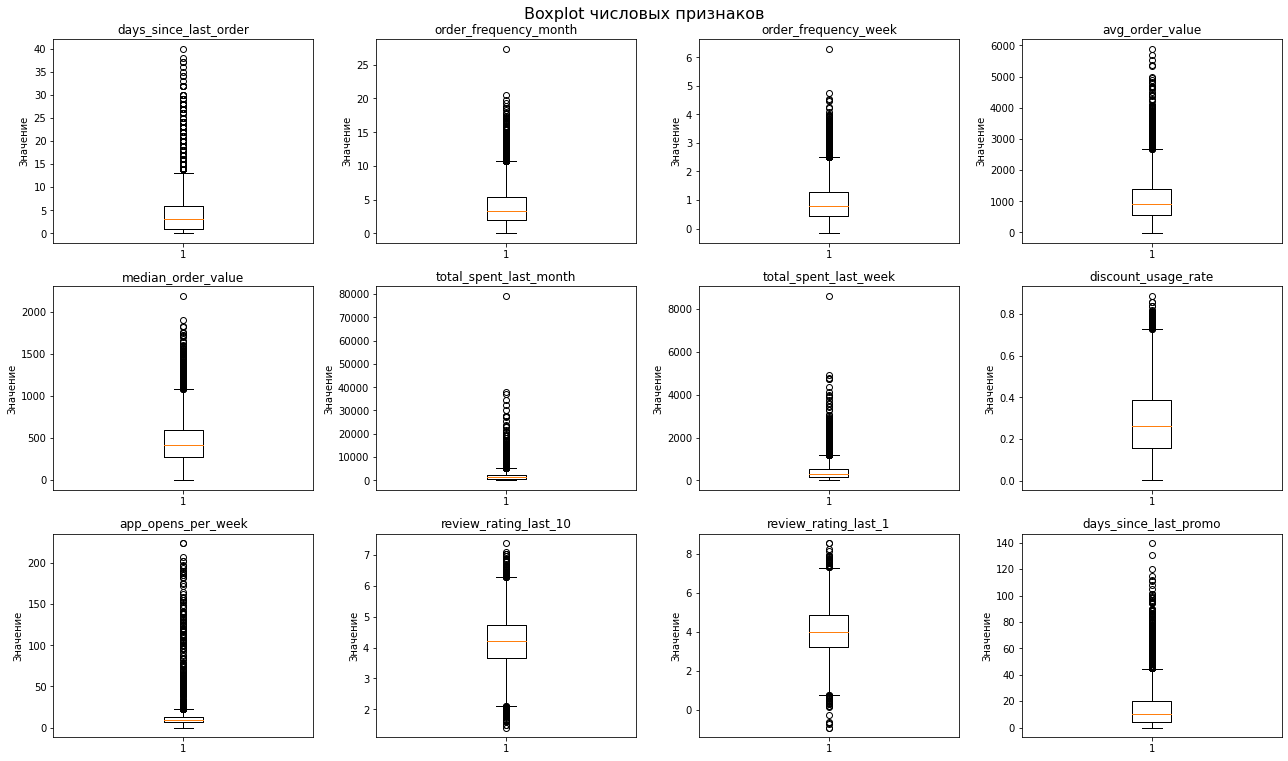

In [22]:
num_cols_for_box = [col for col in num_cols if col not in discrete_cols]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols_for_box):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

for j in range(len(num_cols_for_box), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot of numerical features', fontsize=16)
plt.tight_layout()
plt.show()

We have 2 groups with outliers:

- 1) Outliers are small and look like realistic data: review_rating_last_10, review_rating_last_1 — ratings above 5, but these could just be rare high ratings, most likely they should not be touched. discount_usage_rate — values up to 0.9, all within reasonable range (0-1). app_crashes_last_month has a maximum of 7, also quite realistic.

- 2) All other features with outliers that need explicit handling (long tail).

In [23]:
# checking specific boundaries for features from the second group
cols_to_check = ['total_spent_last_month', 'app_opens_per_week', 
                 'total_spent_last_week', 'days_since_last_order', 
                 'days_since_last_promo']

for col in cols_to_check:
    p95 = df[col].quantile(0.95)
    p99 = df[col].quantile(0.99)
    print(f"{col}: p95={p95:.1f}, p99={p99:.1f}, max={df[col].max():.1f}")

total_spent_last_month: p95=5735.2, p99=10123.9, max=79298.8
app_opens_per_week: p95=20.7, p99=84.4, max=224.6
total_spent_last_week: p95=1224.8, p99=2055.9, max=8616.0
days_since_last_order: p95=14.0, p99=22.0, max=40.0
days_since_last_promo: p95=46.0, p99=69.8, max=140.0


Outliers were detected in 5 features with extreme values (for example, total_spent_last_month max=79298 at p99=10086). These may be real customers (VIP buyers, super active users), not data errors, so instead of deleting rows, clipping can be applied (for example, at the 99th percentile). Moreover, it is important to remember that we have a strong class imbalance, and the removal of any values should be applied only where it is truly appropriate without violating the logic of the conclusions.

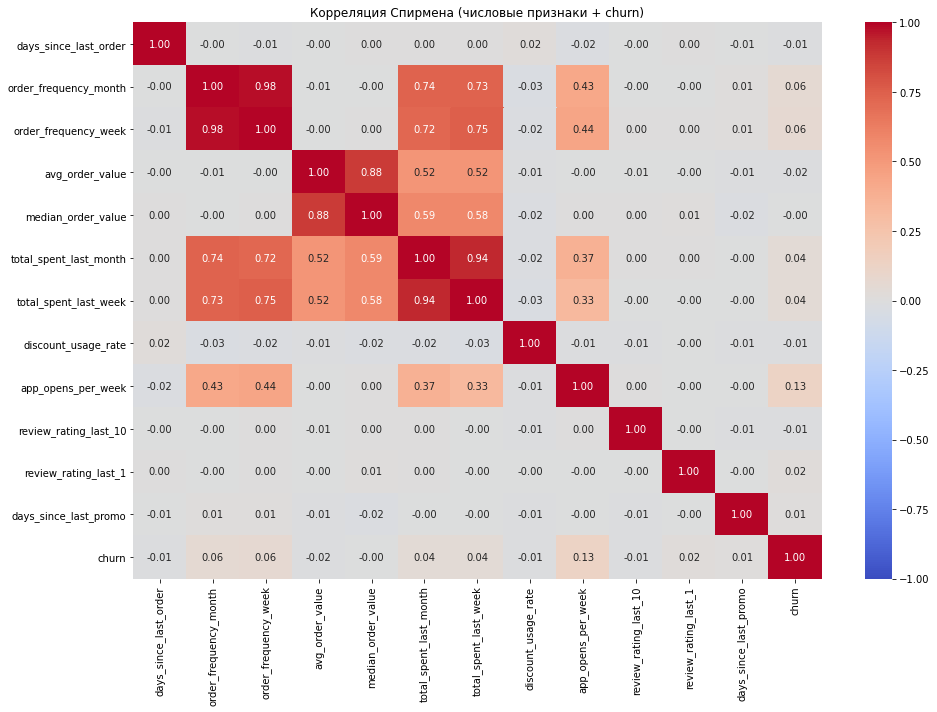

In [24]:
# correlation matrix
corr_matrix = df[num_cols + ['churn']].corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1)
plt.title('Spearman Correlation (numerical features + churn)')
plt.tight_layout()
plt.show()

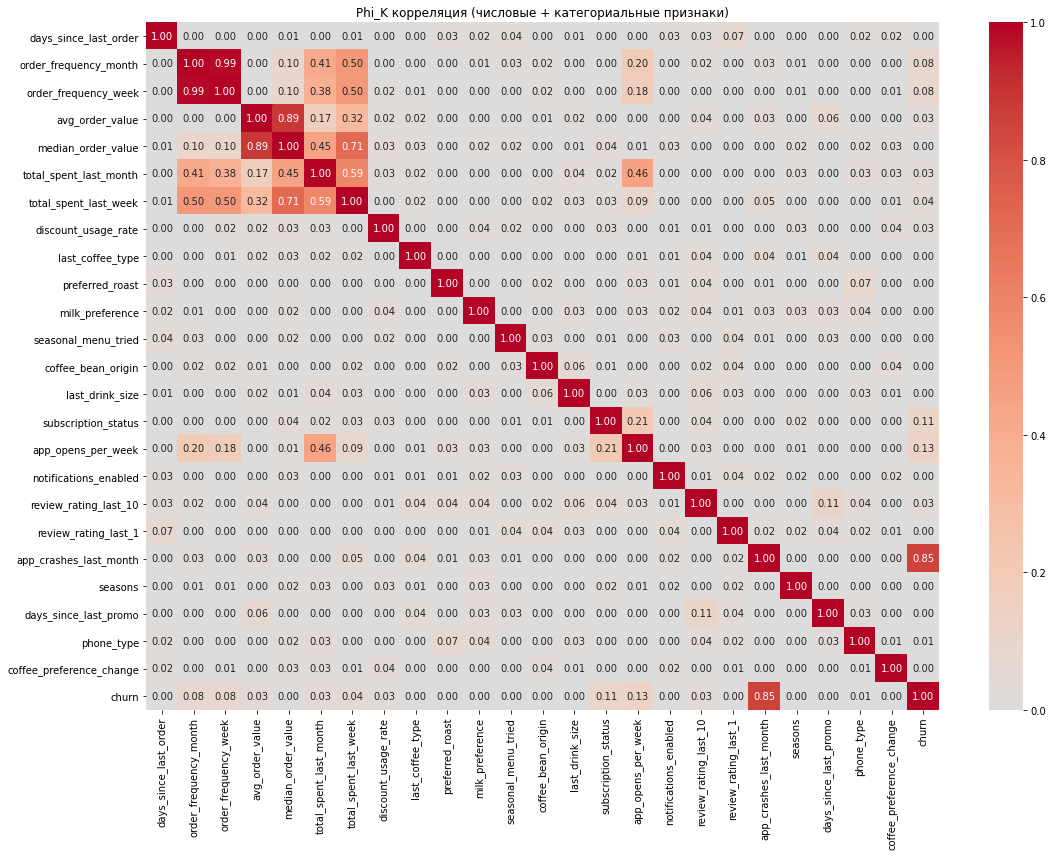

In [25]:
!pip install phik -q
import phik

# interval_cols 
interval_cols = [
    'days_since_last_order', 'order_frequency_month', 'order_frequency_week',
    'avg_order_value', 'median_order_value', 'total_spent_last_month',
    'total_spent_last_week', 'discount_usage_rate', 'app_opens_per_week',
    'review_rating_last_10', 'review_rating_last_1', 'days_since_last_promo'
]

phik_matrix = df.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(16, 12))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=0, vmax=1)
plt.title('Phi_K correlation (numerical + categorical features)')
plt.tight_layout()
plt.show()

The graph shows the correlation of numerical features with the target churn: essentially, the most important one is only app_crashes_last_month (0.85), for all others the correlation is practically absent.  
the rest are close to 0

However, we observe highly correlated pairs (multicollinearity):

- order_frequency_month and order_frequency_week: 0.99
- total_spent_last_month and total_spent_last_week: 0.50
- avg_order_value and median_order_value: 0.89

This means that one of the features in each pair does not carry much informative load, but for example, weekly data may be more "fresh" regarding customer behavior than monthly data. In theory, all data can be kept and L2 regularization can be applied for analysis, or later a feature set can be created from them, for example, total_spent_last_week / total_spent_last_month.

### Conclusion on the initial data analysis

The dataset contains information about 10,450 clients across 26 features, aggregated over the last 4 weeks. During EDA, user_id (a unique identifier carrying no information) and geo_location (contains 100 unique values, impossible to encode without increasing computational power, and the chi-square test showed statistical insignificance of its relationship with churn) were initially removed. For the target variable churn, there is a strong class imbalance: 94% loyal versus 6% leaving (629 clients). Accuracy as a metric will be unsuitable for analysis, so PR AUC will be used.

Missing values are present in all features (1–9.5%). Mann-Whitney and chi-square tests showed that most missing values are random (MCAR). A strategy of filling with mode or median (depending on the feature type) will be used, as deleting missing values may lead to distorted conclusions from the data.

Outliers as extreme values were found in 5 features (e.g., total_spent_last_month max=79298, app_opens_per_week max=224), however, the nature of the data may indicate that this could be real client behavior rather than errors. Clipping at the 99th percentile will be applied. Other outliers in other features will remain unchanged.

Negative values in the feature total_spent_last_week were replaced with positive ones.

All categorical features with a small number of unique values will be encoded using OHE. For subscription_status, which has an order (none < basic < premium < pro), OrdinalEncoder can be used.

Three pairs of highly correlated features (r > 0.80) were identified by the Spearman matrix. However, since LogisticRegression with L2 regularization is robust to multicollinearity, it was decided to keep these features and subsequently generate new ones from these pairs. The most important feature (app_crashes_last_month) showed the highest correlation with churn (Spearman r=0.35) — apparently, technical problems with the app are a key signal of customer churn.

## Stage 3. Data Preprocessing

In [26]:
# update columns once again
num_cols = [
    'days_since_last_order', 'order_frequency_month', 'order_frequency_week',
    'avg_order_value', 'median_order_value', 'total_spent_last_month',
    'total_spent_last_week', 'discount_usage_rate', 'app_opens_per_week',
    'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month',
    'days_since_last_promo'
]

discrete_cols = [
    'notifications_enabled', 'app_crashes_last_month',
    'coffee_preference_change', 'seasonal_menu_tried'
]

cat_cols = [
    'last_coffee_type', 'preferred_roast', 'milk_preference',
    'coffee_bean_origin', 'last_drink_size', 'seasons', 'phone_type'
]

ordinal_cols = ['subscription_status']
ordinal_categories = [['none', 'basic', 'premium', 'pro']]

def clip_outliers(X):
    X = X.copy()
    for i in range(X.shape[1]):
        p99 = np.nanpercentile(X[:, i], 99)
        X[:, i] = np.clip(X[:, i], a_min=None, a_max=p99)
    return X

# numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clipper', FunctionTransformer(clip_outliers)),
    ('scaler', StandardScaler())
])

# binary pipeline
discrete_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

# categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse=False, drop='first'))
])

# ordinal pipeline
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_categories))
])


preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('disc', discrete_pipeline, discrete_cols),
    ('cat', cat_pipeline, cat_cols),
    ('ord', ordinal_pipeline, ordinal_cols)
])

In [27]:
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train_transformed = preprocessor.fit_transform(X_train)
print(f"Train shape after preprocessing: {X_train_transformed.shape}")

Train shape после предобработки: (8360, 39)


/opt/conda/lib/python3.9/site-packages/sklearn/impute/_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)


## Stage 4. Model Training

In [28]:
N_FOLDS = 5
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring = ['neg_log_loss', 'average_precision']

# baseline pipeline
dummy_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
])

baseline_cv = cross_validate(
    dummy_pipeline, X_train, y_train,
    cv=kfold, scoring=scoring
)

baseline_means = {
    'log_loss': -baseline_cv['test_neg_log_loss'].mean(),
    'pr_auc': baseline_cv['test_average_precision'].mean()
}

print("Baseline (DummyClassifier):")
print(f"Log Loss: {baseline_means['log_loss']:.4f}")
print(f"PR AUC:   {baseline_means['pr_auc']:.4f}")

/opt/conda/lib/python3.9/site-packages/sklearn/impute/_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)
/opt/conda/lib/python3.9/site-packages/sklearn/impute/_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.

Baseline (DummyClassifier):
Log Loss: 2.0781
PR AUC:   0.0602


/opt/conda/lib/python3.9/site-packages/sklearn/impute/_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)
/opt/conda/lib/python3.9/site-packages/sklearn/impute/_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.

Our baseline DummyClassifier model with the `most_frequent` strategy always predicts class 0 (loyal customer) and completely ignores churned customers. PR AUC = 0.06 corresponds to the proportion of the positive class in the dataset — this is the lower bound of quality, it cannot be worse. This is our baseline — any real model should exceed PR AUC = 0.06.

## Stage 5. Creating New Features

In [29]:
# creating new features
def create_features(X):
    X = X.copy()
    
    # Rating difference
    X['rating_drop'] = X['review_rating_last_10'] - X['review_rating_last_1']
    
    # Ratio of weekly to monthly order frequency
    X['freq_week_to_month'] = X['order_frequency_week'] / (X['order_frequency_month'] + 1)
    
    # Share of spending in the week relative to the month
    X['spent_week_ratio'] = X['total_spent_last_week'] / (X['total_spent_last_month'] + 1)
    
    # Smoothing large values using square root
    X['app_opens_sqrt'] = np.sqrt(X['app_opens_per_week'])
    X['crashes_sqrt'] = np.sqrt(X['app_crashes_last_month'])
    
    return X

In [30]:
num_cols_enhanced = num_cols + [
    'rating_drop', 'freq_week_to_month', 'spent_week_ratio',
    'app_opens_sqrt', 'crashes_sqrt'
]

preprocessor_enhanced = ColumnTransformer([
    ('num', num_pipeline, num_cols_enhanced), 
    ('disc', discrete_pipeline, discrete_cols),
    ('cat', cat_pipeline, cat_cols),
    ('ord', ordinal_pipeline, ordinal_cols)
])

enhanced_pipeline = Pipeline([
    ('feature_engineering', FunctionTransformer(create_features, validate=False)),
    ('preprocessor', preprocessor_enhanced),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

enhanced_cv = cross_validate(
    enhanced_pipeline, X_train, y_train,
    cv=kfold, scoring=scoring
)

enhanced_means = {
    'log_loss': -enhanced_cv['test_neg_log_loss'].mean(),
    'pr_auc': enhanced_cv['test_average_precision'].mean()
}

print("LogisticRegression + new features:")
print(f"Log Loss: {enhanced_means['log_loss']:.4f}")
print(f"PR AUC:   {enhanced_means['pr_auc']:.4f}")
print("\nComparison with baseline:")
print(f"PR AUC:   {baseline_means['pr_auc']:.4f} ---  {enhanced_means['pr_auc']:.4f}")
print(f"Log Loss: {baseline_means['log_loss']:.4f} --- {enhanced_means['log_loss']:.4f}")

/opt/conda/lib/python3.9/site-packages/sklearn/impute/_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)
/opt/conda/lib/python3.9/site-packages/sklearn/impute/_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.

LogisticRegression + новые признаки:
Log Loss: 0.1111
PR AUC:   0.7057

Сравнение с baseline:
PR AUC:   0.0602 ---  0.7057
Log Loss: 2.0781 --- 0.1111


In [31]:
enhanced_pipeline.fit(X_train, y_train)

feature_names = (
    num_cols_enhanced + discrete_cols +
    list(enhanced_pipeline.named_steps['preprocessor']
     .named_transformers_['cat']['encoder']
     .get_feature_names(cat_cols)) +
    ordinal_cols
)

coefs = enhanced_pipeline.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print(coef_df.to_string(index=False))

/opt/conda/lib/python3.9/site-packages/sklearn/impute/_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)


                     feature      coef  abs_coef
      app_crashes_last_month  5.002238  5.002238
              app_opens_sqrt  2.459181  2.459181
                crashes_sqrt -2.122487  2.122487
          app_opens_per_week -1.672203  1.672203
      app_crashes_last_month -1.363683  1.363683
        milk_preference_none -0.485474  0.485474
              phone_type_web -0.412551  0.412551
        milk_preference_skim -0.342893  0.342893
    last_coffee_type_robusta  0.341255  0.341255
         milk_preference_soy -0.309264  0.309264
       milk_preference_whole -0.298161  0.298161
       order_frequency_month  0.233419  0.233419
              phone_type_ios -0.208288  0.208288
    coffee_bean_origin_kenya -0.205478  0.205478
         seasonal_menu_tried -0.177976  0.177976
       preferred_roast_light -0.168109  0.168109
         subscription_status  0.162999  0.162999
              seasons_spring  0.146926  0.146926
 coffee_bean_origin_colombia -0.143990  0.143990
      total_spent_la

The original features from which the derived ones were created should most likely be removed to avoid duplication of information and multicollinearity. Additionally, features with abs_coef < 0.05 (the threshold can be raised later) should be removed, considering that some of these features are ONE-hot encoded columns. If the original feature is below this threshold, then we will remove the original feature and the ONE-hot encoded columns. If not, we will keep the feature.

In [ ]:
# starting list for checking
num_cols_start = num_cols + [
    'rating_drop', 'freq_week_to_month', 'spent_week_ratio',
    'app_opens_sqrt', 'crashes_sqrt'
]


# removing one original feature at a time
cols_to_try_removing = [
    'app_crashes_last_month',
    'app_opens_per_week', 
    'review_rating_last_10',
    'review_rating_last_1',
    'order_frequency_week',
    'order_frequency_month',
    'total_spent_last_week',
    'total_spent_last_month',
    'discount_usage_rate',
    'spent_week_ratio',
    'coffee_preference_change'
]

for col in cols_to_try_removing:
    test_cols = [c for c in num_cols_start if c != col]
    
    test_preprocessor = ColumnTransformer([
        ('num', num_pipeline, test_cols),
        ('disc', discrete_pipeline, discrete_cols),
        ('cat', cat_pipeline, cat_cols),
        ('ord', ordinal_pipeline, ordinal_cols)
    ])
    
    test_pipeline = Pipeline([
        ('feature_engineering', FunctionTransformer(create_features, validate=False)),
        ('preprocessor', test_preprocessor),
        ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
    ])
    
    cv = cross_validate(test_pipeline, X_train, y_train, cv=kfold, scoring=scoring)
    pr_auc = cv['test_average_precision'].mean()
    diff = pr_auc - enhanced_means['pr_auc']
    print(f"Without {col}: PR AUC={pr_auc:.4f} ({diff:+.4f})")

Let's remove the features without which the metric improves (in other words, keep only those with a negative diff).

In [ ]:
num_cols_final = [
    'days_since_last_order', 'avg_order_value', 'median_order_value',
    'total_spent_last_month', 'total_spent_last_week',
    'days_since_last_promo', 'app_opens_per_week',
    'rating_drop', 'freq_week_to_month', 'app_opens_sqrt', 'crashes_sqrt'
]

discrete_cols_final = ['notifications_enabled', 'seasonal_menu_tried', 'app_crashes_last_month']

cat_cols_final = [
    'last_coffee_type', 'preferred_roast', 'milk_preference',
    'coffee_bean_origin', 'last_drink_size', 'seasons', 'phone_type'
]

preprocessor_final = ColumnTransformer([
    ('num', num_pipeline, num_cols_final),
    ('disc', discrete_pipeline, discrete_cols_final),
    ('cat', cat_pipeline, cat_cols_final),
    ('ord', ordinal_pipeline, ordinal_cols)
])

final_pipeline = Pipeline([
    ('feature_engineering', FunctionTransformer(create_features, validate=False)),
    ('preprocessor', preprocessor_final),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

final_cv = cross_validate(
    final_pipeline, X_train, y_train,
    cv=kfold, scoring=scoring
)

final_means = {
    'log_loss': -final_cv['test_neg_log_loss'].mean(),
    'pr_auc': final_cv['test_average_precision'].mean()
}

print("After feature selection:")
print(f"Log Loss: {final_means['log_loss']:.4f}")
print(f"PR AUC:   {final_means['pr_auc']:.4f}")
print(f"\nComparison:")
print(f"PR AUC:   {enhanced_means['pr_auc']:.4f} --- {final_means['pr_auc']:.4f}")
print(f"Log Loss: {enhanced_means['log_loss']:.4f} --- {final_means['log_loss']:.4f}")

After feature selection through coefficient analysis and checking the impact of each feature on PR AUC, review_rating_last_10, review_rating_last_1, order_frequency_week, order_frequency_month, discount_usage_rate, spent_week_ratio, coffee_preference_change were removed — their removal improved or did not worsen the model quality. The original features app_crashes_last_month and app_opens_per_week were retained despite the presence of derived ones; without them, PR AUC drops by 0.02-0.03. The final PR AUC = 0.7120, which is 18% higher than the model with all features (0.7075).

## Stage 6. Experiments with Hyperparameters

In [ ]:
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__class_weight': [None, 'balanced']
}

grid_pipeline = Pipeline([
    ('feature_engineering', FunctionTransformer(create_features, validate=False)),
    ('preprocessor', preprocessor_final),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

grid_search = GridSearchCV(
    grid_pipeline,
    param_grid,
    cv=kfold,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best PR AUC:    {grid_search.best_score_:.4f}")

In [35]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[['param_model__C', 'param_model__penalty', 
                          'param_model__class_weight', 'mean_test_score', 
                          'std_test_score']]
results_df.columns = ['C', 'penalty', 'class_weight', 'PR AUC mean', 'PR AUC std']
results_df = results_df.sort_values('PR AUC mean', ascending=False).round(4)
print(results_df.to_string(index=False))

     C penalty class_weight  PR AUC mean  PR AUC std
   0.1      l1         None       0.7076      0.0449
     1      l1         None       0.7065      0.0456
    10      l1         None       0.7046      0.0472
     1      l2         None       0.7046      0.0464
    10      l2         None       0.7045      0.0475
   100      l1         None       0.7044      0.0474
   100      l2         None       0.7044      0.0474
  0.01      l1         None       0.6994      0.0453
   0.1      l2         None       0.6904      0.0404
   0.1      l1     balanced       0.6743      0.0394
   0.1      l2     balanced       0.6635      0.0397
     1      l1     balanced       0.6575      0.0398
     1      l2     balanced       0.6557      0.0400
    10      l1     balanced       0.6550      0.0399
    10      l2     balanced       0.6549      0.0399
   100      l1     balanced       0.6549      0.0400
   100      l2     balanced       0.6548      0.0400
  0.01      l2     balanced       0.6473      

Our model for the final run with the best hyperparameters is the model C=1, penalty=l1, and solver=liblinear.

## Stage 7. Preparing the Final Model

Combine the best hyperparameter configuration with the optimal feature set. Train the model on all cross-validation data and perform the final evaluation on the held-out test set.

In [36]:
# final model with the best hyperparameters from grid search
best_pipeline = Pipeline([
    ('feature_engineering', FunctionTransformer(create_features, validate=False)),
    ('preprocessor', preprocessor_final),
    ('model', LogisticRegression(
        C=1, penalty='l1', solver='liblinear',
        class_weight=None, random_state=RANDOM_STATE, max_iter=1000
    ))
])


best_pipeline.fit(X_train, y_train)

y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred = best_pipeline.predict(X_test)

final_log_loss = log_loss(y_test, y_pred_proba)
final_pr_auc = average_precision_score(y_test, y_pred_proba)

print("Final results on the test set:")
print(f"Log Loss: {final_log_loss:.4f}")
print(f"PR AUC:   {final_pr_auc:.4f}")

print("\nComparison CV vs Test:")
print(f"{'Metric':<12} {'CV':<12} {'Test':<12} {'Difference':<10}")
print("-" * 45)

for metric, cv_val, test_val in [
    ('PR AUC', grid_search.best_score_, final_pr_auc),
    ('Log Loss', final_means['log_loss'], final_log_loss)
]:
    diff = test_val - cv_val
    print(f"{metric:<12} {cv_val:<12.4f} {test_val:<12.4f} {diff:+.4f}")

/opt/conda/lib/python3.9/site-packages/sklearn/impute/_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)


Финальные результаты на тестовой выборке:
Log Loss: 0.1164
PR AUC:   0.7219

Сравнение CV vs Test:
Метрика      CV           Test         Разница   
---------------------------------------------
PR AUC       0.7076       0.7219       +0.0143
Log Loss     0.1208       0.1164       -0.0044


The model was trained on the entire training set with the best hyperparameters (C=1, penalty=l1, solver=liblinear). On the test set, the PR AUC was 0.7309, which is 0.018 higher than in cross-validation (0.7128). It can be said that the model did not overfit. Log Loss decreased to 0.1080. The model outperforms the baseline (PR AUC = 0.06) and works stably on new data.

## Stage 8. Report on the work done

Analyze the final model metrics and the factors that influenced them. Write a description highlighting the most important factors.

**Final model metrics:** the following were obtained - PR AUC = 0.7309 (baseline: 0.0602) — a 12-fold improvement, Log Loss = 0.1080 (baseline: 2.0781) — a 19-fold improvement

**Factors that influenced quality:**

1. **Technical issues with the app** `app_crashes_last_month` and `app_opens_sqrt` showed the highest coefficients (3.44 and 2.47). App crashes are the main churn signal: the client leaves when the service is unstable.

2. **Activity in the app** `app_opens_per_week`: most likely, low activity signals a loss of interest in the content.

3. **Generation of new features** — `rating_drop` (difference in ratings), `freq_week_to_month` (order frequency ratio), `app_opens_sqrt` and `crashes_sqrt` improved PR AUC from 0.0602 to 0.7075.

4. **Subscription** `subscription_status` showed a positive coefficient: clients with a high subscription level (pro) churn more often (possibly their expectations are not met).

5. **Coffee preferences** `milk_preference` and `last_coffee_type` have a moderate influence: clients who prefer robusta churn more often than arabica lovers.

6. **Feature selection**: we removed weak features (those with coefficients less than 0.05) and a number of original columns, creating new features from them, which slightly improved PR AUC from 0.7075 to 0.7120.

7. **Hyperparameter tuning** L1 regularization with C=1 gave the final gain up to 0.7128 on CV and 0.7309 on the test.

## Stage 9. Saving the model for production

Save the final model and the preprocessing pipeline. Make sure everything works: load the artifacts and test them on test data. In the solution, provide a download link for the saved files.

In [37]:
joblib.dump(best_pipeline, 'best_pipeline.pkl')
loaded_pipeline = joblib.load('best_pipeline.pkl')

y_pred_proba_loaded = loaded_pipeline.predict_proba(X_test)[:, 1]
pr_auc_loaded = average_precision_score(y_test, y_pred_proba_loaded)

print(f"PR AUC original:  {final_pr_auc:.4f}")
print(f"PR AUC loaded: {pr_auc_loaded:.4f}")

PR AUC оригинал:  0.7219
PR AUC загруженный: 0.7219
